# 垃圾邮件分类 - 基于朴素贝叶斯算法

### 什么是朴素贝叶斯算法？
朴素贝叶斯（Naive Bayes）是一种基于**贝叶斯定理**与**特征条件独立假设**的分类方法。
- **“贝叶斯”**：它利用概率统计知识，通过已知的先验概率和条件概率来计算后验概率。
- **“朴素”**：它假设输入特征（在本项目中是邮件里的单词）之间是相互独立的。虽然这个假设在现实中往往不成立，但该算法在文本分类任务中表现极其出色且计算效率极高。

### 垃圾邮件分类的意义
1. **提升效率**：自动过滤无关推广和骚扰信息，帮助用户专注于重要邮件，节省处理时间。
2. **安全防护**：识别包含钓鱼链接、恶意软件或诈骗信息的邮件，防止个人信息泄露与财产损失。
3. **资源优化**：减少邮件服务器的存储压力及带宽消耗。

本项目将演示如何从零开始实现一个简单的多项式朴素贝叶斯分类器。

In [1]:
import os
import re
import string
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

## 1. 数据读取与准备

首先，我们需要从指定的目录中加载所有的邮件内容。由于原始数据以文本文件形式存储在不同的子目录下，我们定义一个函数来递归读取内容，并将它们转换为模型可以处理的格式。正常邮件标记为 `0`，垃圾邮件标记为 `1`。

In [2]:
#在这个代码段中，我们读入了所有邮件内容和标签，其中邮件内容存储在data中，
#标签存储在target当中，“1”表示为垃圾邮件，“0”表示为正常邮件。
DATA_DIR = 'enron'
target_names = ['ham', 'spam']
def get_data(DATA_DIR):
    subfolders = ['enron%d' % i for i in range(1,7)]
    data = []
    target = []
    for subfolder in subfolders:
        # spam
        spam_files = os.listdir(os.path.join(DATA_DIR, subfolder, 'spam'))
        for spam_file in spam_files:
            with open(os.path.join(DATA_DIR, subfolder, 'spam', spam_file), encoding="latin-1") as f:
                data.append(f.read())
                target.append(1)
        # ham
        ham_files = os.listdir(os.path.join(DATA_DIR, subfolder, 'ham'))
        for ham_file in ham_files:
            with open(os.path.join(DATA_DIR, subfolder, 'ham', ham_file), encoding="latin-1") as f:
                data.append(f.read())
                target.append(0)
    return data, target
 
X, y = get_data(DATA_DIR)#读取数据

## 2. 数据可视化

在开始建模之前，了解数据集中不同类别邮件的分布情况非常重要。我们使用 Seaborn 和 Matplotlib 来绘制直方图。

C:\Users\86131\AppData\Local\Temp\ipykernel_67272\1041910104.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_names, y=counts, palette='viridis')


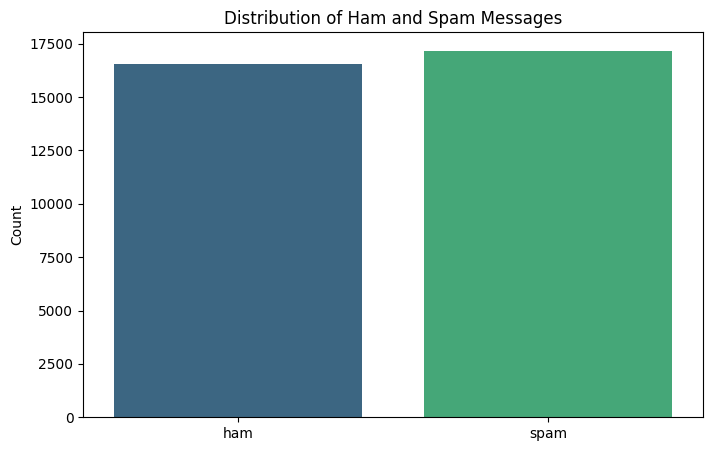

In [3]:
counts = [y.count(0), y.count(1)]
plt.figure(figsize=(8, 5))
sns.barplot(x=target_names, y=counts, palette='viridis')
plt.title('Distribution of Ham and Spam Messages')
plt.ylabel('Count')
plt.show()

## 3. 文本预处理

机器学习算法无法直接处理原始文本。我们需要定义一个预处理类，用于转换文本：
- **清除标点符号**：去除对分类没有实际意义的符号。
- **分词 (Tokenization)**：将字符串拆分为单个单词，并转换为小写。
- **词频统计**：统计每个单词在邮件中出现的频率。

In [4]:
#定义一个类对数据进行预处理
class SpamDetector_1(object):
    #清除标点符号
    def clean(self, s):
        translator = str.maketrans("", "", string.punctuation)
        return s.translate(translator)
    #将字符串标记为单词
    def tokenize(self, text):
        text = self.clean(text).lower()
        return re.split("\W+", text)
    #计算某个单词出现的次数
    def get_word_counts(self, words):
        word_counts = {}
        for word in words:
            word_counts[word] = word_counts.get(word, 0.0) + 1.0
        return word_counts

## 4. 模型训练 (朴素贝叶斯)

接下来，我们构建训练模型。这包括：
1. **计算先验概率**：即计算 P(Spam) 和 P(Ham)。
2. **构建词汇表**：收集所有在垃圾邮件和正常邮件中出现的唯一单词。
3. **统计词频**：统计给定单词在各类别邮件中出现的次数，为后续计算条件概率做准备。

In [5]:
#在我们开始实际算法之前，我们需要做三件事：
# 计算（对数）类先验，即计算P（垃圾邮件）和P（正常邮件）；
# 词汇表（即正常邮件和垃圾邮件中出现的所有单词，方便进行拉普拉斯平滑）；
# 垃圾邮件和非垃圾邮件的词频，即给定词在垃圾邮件和非垃圾邮件中出现的次数。
class SpamDetector_2(SpamDetector_1):
    # X:data,Y:target标签（垃圾邮件或正常邮件）
    def fit(self, X, Y):
        self.num_messages = {}
        self.log_class_priors = {}
        self.word_counts = {}
        # 建立一个集合存储所有出现的单词
        self.vocab = set()
        # 统计spam和ham邮件的个数
        self.num_messages['spam'] = sum(1 for label in Y if label == 1)
        self.num_messages['ham'] = sum(1 for label in Y if label == 0)
 
        # 计算先验概率，即所有的邮件中，垃圾邮件和正常邮件所占的比例
        self.log_class_priors['spam'] = math.log(
            self.num_messages['spam'] / (self.num_messages['spam'] + self.num_messages['ham']))
        self.log_class_priors['ham'] = math.log(
            self.num_messages['ham'] / (self.num_messages['spam'] + self.num_messages['ham']))
 
        self.word_counts['spam'] = {}
        self.word_counts['ham'] = {}
 
        for x, y in zip(X, Y):
            c = 'spam' if y == 1 else 'ham'
            # 构建一个字典存储单封邮件中的单词以及其个数
            counts = self.get_word_counts(self.tokenize(x))
            for word, count in counts.items():
                if word not in self.vocab:
                    self.vocab.add(word)#确保self.vocab中含有所有邮件中的单词
                # 下面语句是为了计算垃圾邮件和非垃圾邮件的词频，即给定词在垃圾邮件和非垃圾邮件中出现的次数。
                # c是0或1，垃圾邮件的标签
                if word not in self.word_counts[c]:
                    self.word_counts[c][word] = 0.0
                self.word_counts[c][word] += count

## 5. 模型验证与调试

我们选取数据的前 100 封邮件之外的部分作为训练集，检查模型计算出的类先验概率对数。如果结果与预期相符，则说明逻辑正确。

In [6]:
#可以利用下面的语句进行debug，判断是否运行正确，
#若正确，log_class_priors of spam应该为-0.6776，log_class_priors of ham应该为-0.7089。
#我们选取了第100封之后的邮件作为训练集，前面一百封邮件作为测试集。
MNB = SpamDetector_2()
# 选取了第100封之后的邮件作为训练集，前面一百封邮件作为测试集
MNB.fit(X[100:], y[100:])
 
print("log_class_priors of spam", MNB.log_class_priors['spam']) #-0.6776
print("log_class_priors of ham", MNB.log_class_priors['ham']) #-0.7089

log_class_priors of spam -0.6776210267040288
log_class_priors of ham -0.7089182027290691


## 6. 编写预测算法

通过朴素贝叶斯公式进行推断。我们将使用对数概率来避免多个小数点后的概率相乘导致的数值下溢问题。同时，我们在计算中使用**拉普拉斯平滑 (Laplace Smoothing)**，以处理词汇表中存在但训练集中未出现的单词。

In [7]:
#下面定义一个类 SpamDetector对测试集进行测试,判断是垃圾邮件还是正常邮件
class SpamDetector(SpamDetector_2):
    def predict(self, X):
        result = []
        flag_1 = 0
        # 遍历所有的测试集
        for x in X:
            counts = self.get_word_counts(self.tokenize(x))  # 生成可以记录单词以及该单词出现的次数的字典
            spam_score = 0
            ham_score = 0
            flag_2 = 0
            for word, _ in counts.items():
                if word not in self.vocab: continue
 
                #下面计算P(内容|垃圾邮件)和P(内容|正常邮件),所有的单词都要进行拉普拉斯平滑
                else:
                    # 该单词存在于正常邮件的训练集和垃圾邮件的训练集当中
                    if word in self.word_counts['spam'].keys() and word in self.word_counts['ham'].keys():
                        log_w_given_spam = math.log(
                            (self.word_counts['spam'][word] + 1) / (sum(self.word_counts['spam'].values()) + len(self.vocab)))
                        log_w_given_ham = math.log(
                            (self.word_counts['ham'][word] + 1) / (sum(self.word_counts['ham'].values()) + len(
                                self.vocab)))
                    # 该单词存在于垃圾邮件的训练集当中,但不存在于正常邮件的训练集当中
                    if word in self.word_counts['spam'].keys() and word not in self.word_counts['ham'].keys():
                        log_w_given_spam = math.log(
                            (self.word_counts['spam'][word] + 1) / (sum(self.word_counts['spam'].values()) + len(self.vocab)))
                        log_w_given_ham = math.log( 1 / (sum(self.word_counts['ham'].values()) + len(
                                self.vocab)))
                    # 该单词存在于正常邮件的训练集当中,但不存在于垃圾邮件的训练集当中
                    if word not in self.word_counts['spam'].keys() and word in self.word_counts['ham'].keys():
                        log_w_given_spam = math.log( 1 / (sum(self.word_counts['spam'].values()) + len(self.vocab)))
                        log_w_given_ham = math.log(
                            (self.word_counts['ham'][word] + 1) / (sum(self.word_counts['ham'].values()) + len(
                                self.vocab)))
 
                # 把计算到的P(内容|垃圾邮件)和P(内容|正常邮件)加起来
                spam_score += log_w_given_spam
                ham_score += log_w_given_ham
 
                flag_2 += 1
 
            # 最后，还要把先验加上去，即P(垃圾邮件)和P(正常邮件)
            spam_score += self.log_class_priors['spam']
            ham_score += self.log_class_priors['ham']
 
            # 最后进行预测，如果spam_score > ham_score则标志为1，即垃圾邮件
            if spam_score > ham_score:
                result.append(1)
            else:
                result.append(0)
 
            flag_1 += 1
 
        return result

## 7. 执行模型预测并评估结果

现在，我们使用前 100 封邮件作为测试集，通过我们编写的 `predict` 方法进行预测，并计算模型的准确率。

In [8]:
MNB = SpamDetector()
MNB.fit(X[100:], y[100:])
pred = MNB.predict(X[:100])
true = y[:100]
 
accuracy = 0
for i in range(100):
    if pred[i] == true[i]:
        accuracy += 1
print(accuracy) # 98

98


## 8. 混淆矩阵展示

最后，我们通过混淆矩阵来可视化分类器的表现，查看模型在正例（垃圾邮件）和负例（正常邮件）上的分类细节。

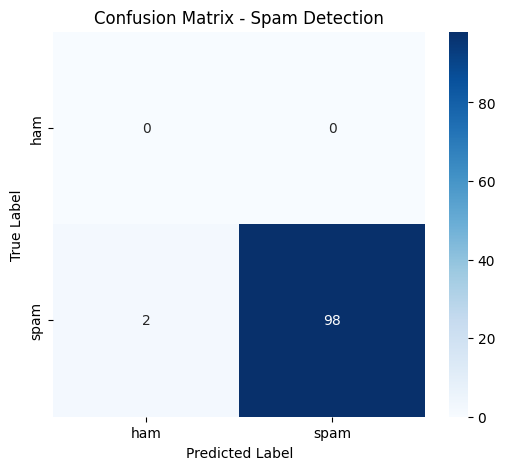

In [9]:
# 生成混淆矩阵
cm = confusion_matrix(true, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Spam Detection')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 9. 教学案例拓展与思考

作为教学案例，本项目可以引导学生从以下几个维度进行深入探究：

### 思考题 1：为什么在计算概率时要使用对数（Log）？如果不使用对数会有什么问题？
- **解答思路**：
  - **数值下溢（Underflow）**：单封邮件可能包含成百上千个单词，每个单词出现的概率通常很小（如 0.001）。如果直接连乘，多个极小数相乘会导致结果迅速接近于 0，超出计算机浮点数的表示范围，从而丢失精度。
  - **计算简化**：取对数后，原本的乘法运算转换为加法运算（$\log(a \cdot b) = \log a + \log b$），通过增加计算效率的同时保证了数值的稳定性。

### 思考题 2：代码中提到的“拉普拉斯平滑（Laplace Smoothing）”具体解决了什么物理意义上的问题？
- **解答思路**：
  - **零概率陷阱**：如果在测试集中出现了一个在训练集中**某类（如垃圾邮件）从未出现过**的单词，那么对应的条件概率 $P(Word|Spam)$ 将为 0。根据贝叶斯公式连乘，整个类别的后验概率会直接变为 0，导致分类器无法做出合理判断。
  - **解决方法**：通过在分子加 1，分母加词汇表总数，赋予未见词一个微小的概率，保证了模型的泛化能力。

### 思考题 3：如果我们要进一步提高该垃圾邮件分类器的准确率，可以从哪些环节入手？
- **解答思路**：
  - **特征优化（NLP 预处理）**：
    - 是否可以引入 **Stopwords（停用词）** 过滤？像 "the", "to" 等高频词对区分垃圾邮件贡献度很低。
    - 是否可以使用 **Stemming（词干提取）**？例如将 "buy", "buying", "bought" 统一处理。
  - **权重改良**：目前的算法是基于单词出现次数的。如果使用 **TF-IDF** 算法，是否能更好地突出那些具有“分类特质”的关键词？
  - **算法选择**：朴素贝叶斯假设特征间独立。但在真实场景中，“中奖”、“点击”、“链接”往往是成对出现的。学生可以思考尝试使用 **N-gram**（如 Bigram）或者更复杂的深度学习模型（如 LSTM, Transformer）来捕捉上下文信息。

### 思考题 4：混淆矩阵（Confusion Matrix）中哪种错误对用户的影响更大？
- **解答思路**：
  - **FP（假阳性/误报）**：将正常邮件误判为垃圾邮件。这可能导致用户错过重要信息（如入职通知、合同附件），代价极大。
  - **FN（假阴性/漏报）**：将垃圾邮件漏判为正常邮件。这只是用户体验上的骚扰，代价相对较小。
  - **结论**：在实际工程中，我们往往会调整分类阈值，尽量降低误报率（提高 Precision），哪怕这会稍微降低对垃圾邮件的拦截能力。

---
希望以上思考题能帮助大家更深刻地理解朴素贝叶斯算法在现实场景中的应用与优化！